In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))



In [10]:
import importlib

import src.pipelines.build_master_dataset as pipeline

importlib.reload(pipeline)

<module 'src.pipelines.build_master_dataset' from 'C:\\Users\\rauni\\Documents\\Learning\\Projects\\ads-intelligence-platform\\src\\pipelines\\build_master_dataset.py'>

In [11]:
from src.analysis.recommendation_audit import RecommendationAudit
from src.pipelines.build_master_dataset import build_master_dataset


In [12]:
master = build_master_dataset(save=False)

In [13]:
master.head() 

,user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,...,video_type,upload_dt,upload_type,visible_status,video_duration,server_width,server_height,music_id,music_type,tag
0,0,1527,20220411,1900,1649675512388,0,0,0,0,0,...,NORMAL,2022-04-10,Web,0.0,209900.0,1172.0,720.0,9154013497,9.0,39
1,0,7405,20220416,2000,1650111976017,0,0,0,0,0,...,NORMAL,2022-04-09,Kmovie,0.0,65400.0,720.0,1280.0,9145692691,9.0,12
2,0,6026,20220420,1600,1650444367095,0,0,0,0,0,...,NORMAL,2022-04-10,Web,0.0,170833.0,720.0,1280.0,9156647291,9.0,39
3,1,6354,20220411,1100,1649645295928,0,0,0,0,0,...,NORMAL,2022-04-10,Web,0.0,255160.0,1280.0,720.0,9154256938,9.0,3
4,1,3645,20220411,1100,1649648827559,0,0,0,0,0,...,NORMAL,2022-04-10,Web,0.0,79733.0,720.0,1280.0,9152899551,9.0,22


In [15]:
master.shape 

(1141112, 60)

In [14]:
RecommendationAudit.interaction_summary(master)

,Metric,Value
0,Total Interactions,1141112.00
1,Unique Users,26210.00
2,Unique Videos,7538.00
3,Click Rate,46.34
4,Like Rate,1.87
5,Follow Rate,0.10
6,Long View Rate,33.66


In [16]:
RecommendationAudit.user_activity(master)

,interactions
count,26210.000000
mean,43.537276
std,44.711028
min,1.000000
25%,13.000000
50%,31.000000
75%,59.000000
max,809.000000


In [17]:
RecommendationAudit.video_popularity(master)

,interactions
count,7538.000000
mean,151.381268
std,365.539152
min,1.000000
25%,16.000000
50%,44.000000
75%,136.000000
max,9110.000000


In [18]:
RecommendationAudit.daily_activity(master)

,date,interactions
0,20220409,52736
1,20220410,227808
2,20220411,278835
3,20220412,166076
4,20220413,94711
5,20220414,71252
6,20220415,58892
7,20220416,60904
8,20220417,44023
9,20220418,24560


In [19]:
RecommendationAudit.hourly_activity(master)

,hour,interactions
0,0,40846
1,1,23389
2,2,14528
3,3,9770
4,4,7754
5,5,9518
6,6,19230
7,7,32665
8,8,39374
9,9,43760


In [20]:
RecommendationAudit.top_users(master)

,user_id,interactions
0,22287,809
1,4592,698
2,21695,578
3,13893,525
4,6234,524
5,8387,499
6,793,497
7,23327,473
8,1702,458
9,25050,456


In [21]:
RecommendationAudit.top_videos(master)

,video_id,interactions
0,6921,9110
1,2303,7914
2,3310,7359
3,1868,6406
4,7136,5793
5,3587,4319
6,4636,3936
7,6714,3789
8,3273,3771
9,7177,3726


In [22]:
possible = (
    master["user_id"].nunique()
    *
    master["video_id"].nunique()
)

density = len(master) / possible

print(f"{density:.8f}")

0.00577571


In [23]:
(
master.groupby("user_id")
.size()
==1
).sum()

np.int64(610)

In [24]:
(
master.groupby("video_id")
.size()
==1
).sum()

np.int64(81)

<Axes: >

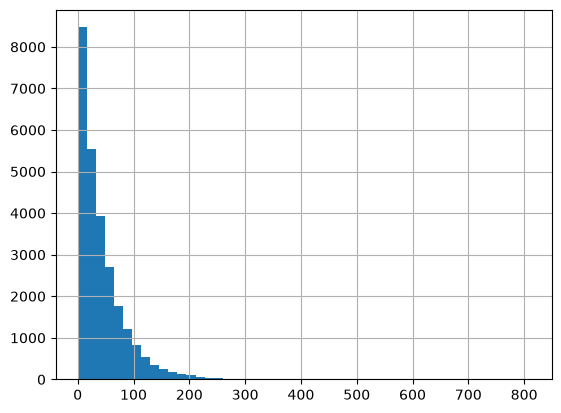

In [25]:
master.groupby("user_id").size().hist(
    bins=50
)

<Axes: >

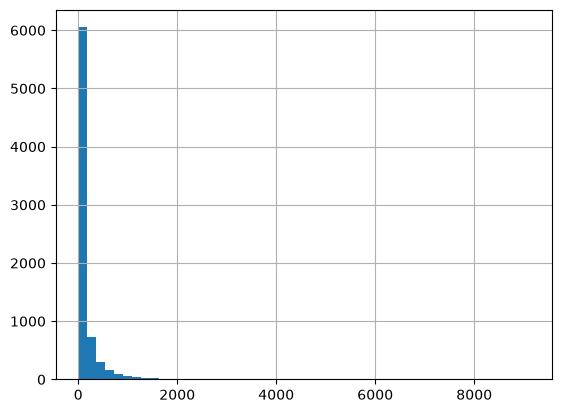

In [26]:

master.groupby("video_id").size().hist(
    bins=50
)

# Recommendation Data Audit

Answering four questions using the outputs already computed above (`interaction_summary`, `user_activity`, `video_popularity`, `daily_activity`, `hourly_activity`, `top_users`, `top_videos`) — no new code, just reasoning over what's already run.

1. Are users active?
2. Which videos are popular?
3. Is the data sparse?
4. How difficult is this recommendation problem?

## 1. Are users active?

### Business Question
Are users engaging repeatedly with the platform, or is engagement dominated by a small handful of power users?

### Observation
From `user_activity` above:

- 26,210 of the platform's 27,285 registered users (96%) generated at least one interaction in this train window.
- Mean interactions/user: **43.5**, median: **31** — mean pulled well above median, so the distribution is right-skewed rather than uniform.
- 25th percentile: 13, 75th percentile: 59 — the middle 50% of users span roughly a 4-5x range.
- Max: **809** (user `22287`), ~26x the median — `top_users` shows the top 20 users (809 down to 379 interactions) all sitting far above the 75th-percentile cutoff of 59.

### Business Impact
Most registered users are active, so there isn't a large dormant majority to worry about. But engagement is heavy-tailed: a handful of power users (hundreds of interactions) will dominate any user-based collaborative-filtering similarity computation or per-user aggregate feature unless capped or regularized. Users near the 25th percentile (~13 interactions) provide a thin signal, closer to cold-start than rich-history. Production ranking should expect **uneven signal density per user**, not a uniform history depth.

## 2. Which videos are popular?

### Business Question
Is video exposure spread broadly across the catalog, or concentrated in a small number of hit videos?

### Observation
From `video_popularity` above:

- 7,538 of the catalog's 7,583 videos (99.4%) received at least one interaction — near-total catalog coverage.
- Mean interactions/video: **151.4**, median: **44** — the mean is more than 3x the median, sharper skew than the user side.
- Std dev (365.5) exceeds the mean, and the max (**9,110**, video `6921`) is over **200x** the median video.
- `top_videos` shows the top 20 (9,110 down to 3,247) all sitting far above the 75th-percentile cutoff of 136.

### Business Impact
Popularity follows a classic power-law/long-tail shape, more concentrated than user activity. A naive "most popular" recommender will score deceptively well on aggregate offline metrics (a few hit videos drive most interactions) while starving the long tail of exposure — a discovery and inventory-fairness problem, and directly relevant to ads: creators/advertisers on long-tail content get negligible reach under a popularity-only policy. This motivates candidate generation (Phase 7) that reserves exploration budget for the tail, rather than ranking purely on historical popularity.

## 3. Is the data sparse?

### Business Question
What fraction of possible user-video pairs actually have an observed interaction — can this support direct collaborative filtering?

### Observation
Using the counts already shown in `interaction_summary` (26,210 unique users × 7,538 unique videos = 197,570,980 possible pairs, against 1,141,112 observed interactions):

$$\text{Sparsity} = 1 - \frac{1{,}141{,}112}{197{,}570{,}980} \approx 99.42\%$$

Fewer than 0.6% of all possible user-video pairs have any observed interaction.

### Business Impact
99.4% sparsity rules out naive dense user-item matrix methods (e.g. plain matrix factorization on raw counts) — there isn't enough direct co-occurrence per user-video pair. This pushes the architecture toward implicit-feedback techniques built for sparse, positive-only signal (e.g. ALS/BPR with negative sampling, or embedding-based two-tower models), and toward leaning on side features (user profile, video metadata) rather than raw interaction history alone — consistent with Phase 4 (Feature Engineering) preceding Phase 6 (Collaborative Filtering) in the roadmap. It also means offline evaluation must be careful: with this few observations per pair, a naive split risks leaking a user's or video's *only* interaction entirely into one side of the split.

## 4. How difficult is this recommendation problem?

### Business Question
Combining activity, popularity, sparsity, and label balance — how hard is this ranking problem, and what does that imply for modeling strategy?

### Observation
Pulling together the outputs above:

- **Extreme sparsity** (99.42%) with **heavy-ta
iled activity on both sides** (users: max 26x median; videos: max ~200x median) — a mix of warm-start and thin-history/cold-start entities.
- **Label imbalance varies sharply by target** (`interaction_summary`): click rate 46.34% (fairly balanced, but reflects impressions already pre-filtered by an existing production policy, not sampled from the full catalog), long-view rate 33.66% (moderate), like rate 1.87% and follow rate 0.1% (severe imbalance) — a multi-task model needs very different handling per head.
- **Traffic is highly non-stationary within the window** (`daily_activity`, `hourly_activity`): daily counts range from 20,021 to 278,835 (~13x variation across 13 days), and hourly counts range from 7,754 (04:00) to 89,105 (22:00), an ~11x swing.

### Business Impact
This is a moderately-to-highly difficult ranking problem — not because click prediction alone is hard (46% base rate is workable), but because (a) sparsity forces reliance on features over raw co-occurrence, (b) secondary engagement objectives (like/follow) are severely imbalanced and need dedicated handling rather than being bolted onto the click model as-is, and (c) strong daily/hourly non-stationarity means time-of-day and day-of-window should likely be explicit features rather than assumed constant. Combined with the video_stats lifetime-aggregate leakage risk identified earlier in this project, the overall implication is that **feature engineering and careful temporal handling (Phase 4) are the highest-leverage next steps**, ahead of a more sophisticated ranking model.

## Key Findings

- 1.14M user-video interactions.
- 26K active users.
- 7.5K videos.
- Sparse interaction matrix (0.58% density).
- Low cold-start problem.
- User activity follows a power-law distribution.
- Video popularity follows a long-tail distribution.
- Evening hours (20:00–22:00) show peak activity.
- Long-view rate (~34%) provides a strong engagement signal.